<img src="http://www.cidaen.es/assets/img/mCIDaeNnb.png" alt="Logo CiDAEN" align="right">


<br><br><br><br>

<h1><font color="#00586D" size=5>Test endpoint de Sagemaker</font></h1>
<br><br>


<div align="right">
<font color="#00586D" size=3>Javier de la Ossa</font><br>
<font color="#00586D" size=3>Máster en Ciencia de Datos e Ingeniería de Datos en la Nube</font><br>
<font color="#00586D" size=3>Universidad de Castilla-La Mancha</font>

</div>

---
<a id="indice"></a>
<h2><font color="#00586D" size=5>Índice</font></h2>


* [1. Inicialización del predictor para interaccionar con el endpoint de Sagemaker](#section1)
* [2. Realización de la inferencia](#section2)
* [3. Observación de los resultados obtenidos](#section3)
* [4. Limpieza de recuersos](#section4)

<br>

---

In [1]:
import boto3, cv2, time, numpy as np, matplotlib.pyplot as plt, random
from sagemaker.pytorch import PyTorchPredictor
from sagemaker.deserializers import JSONDeserializer

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


---

<a id="section1"></a>
## <font color="#00586D"> 1. Inicialización del predictor para interaccionar con el endpoint de Sagemaker</font>
<br>

In [2]:
sm_client = boto3.client(service_name="sagemaker")

# Restore the endpoint name stored in the 1-deploy-sm-endpoint.ipynb notebook
%store -r ENDPOINT_NAME
print(f"Endpoint Name: {ENDPOINT_NAME}")

endpoint_created = False

while True:
    response = sm_client.list_endpoints()
    for ep in response["Endpoints"]:
        print(f"Endpoint Status = {ep['EndpointStatus']}")
        if ep["EndpointName"] == ENDPOINT_NAME and ep["EndpointStatus"] == "InService":
            endpoint_created = True
            break
    if endpoint_created:
        break
    time.sleep(5)

Endpoint Name: yolov8-pytorch-2024-08-24-12-07-51-511813
Endpoint Status = InService


In [3]:
predictor = PyTorchPredictor(endpoint_name=ENDPOINT_NAME,
                             deserializer=JSONDeserializer())

<a id="section2"></a>
## <font color="#00586D"> 2. Realización de la inferencia</font>
<br>

In [16]:
infer_start_time = time.time()

orig_image = cv2.imread("samples/mercadona_00004.png")

image_height, image_width, _ = orig_image.shape
model_height, model_width = 640, 320
x_ratio = image_width/model_width
y_ratio = image_height/model_height

resized_image = cv2.resize(orig_image, (model_width, model_height))
payload = cv2.imencode(".jpg", resized_image)[1].tobytes()
result = predictor.predict(payload)

infer_end_time = time.time()

print(f"Inference Time = {infer_end_time - infer_start_time:0.4f} seconds")

Inference Time = 0.2877 seconds


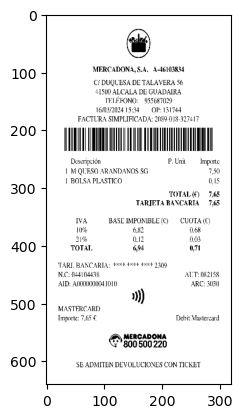

In [17]:
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.show()

<a id="section3"></a>
## <font color="#00586D"> 3. Observación de los resultados obtenidos</font>
<br>

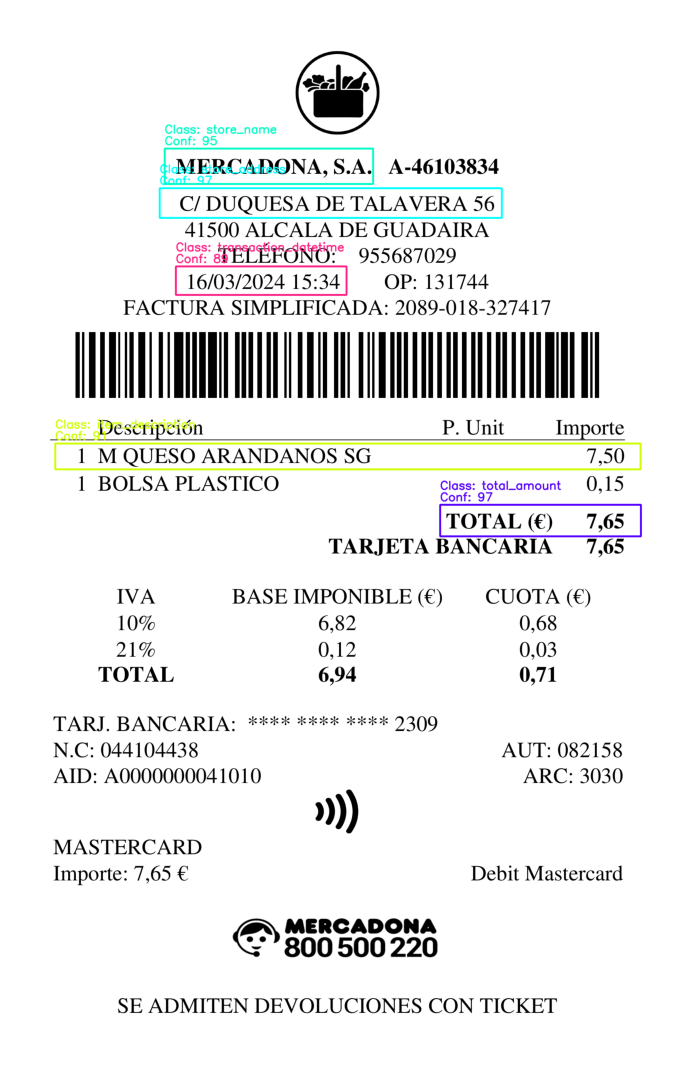

In [18]:
dpi = 200
image_copy = orig_image.copy()
classes_mapper = {0: "item_description", 1: "store_address", 2: "store_name", 3: "total_amount", 4: "transaction_datetime"}
figsize = (image_width / dpi, image_height / dpi)


if 'boxes' in result:
    for idx,(x1,y1,x2,y2,conf,lbl) in enumerate(result['boxes']):
        if conf < 0.5:
            continue
        
        # Draw Bounding Boxes
        x1, x2 = int(x_ratio*x1), int(x_ratio*x2)
        y1, y2 = int(y_ratio*y1), int(y_ratio*y2)
        
        # Map label int with its text value
        lbl_name = classes_mapper.get(lbl)
        
        # Choose a color for the bounding box
        if lbl_name == "item_description":
            color = (0, 255, 206)
        elif lbl_name == "store_address":
            color = (255, 255, 0)
        elif lbl_name == "store_name":
            color = (199, 252, 0)
        elif lbl_name == "total_amount":
            color = (254, 0, 86)
        else:
            color = (134, 34, 255)  
        
        # color = (random.randint(10,255), random.randint(10,255), random.randint(10,255))
        cv2.rectangle(image_copy, (x1,y1), (x2,y2), color, 4)
        cv2.putText(image_copy, f"Class: {lbl_name}", (x1,y1-40), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)
        cv2.putText(image_copy, f"Conf: {int(conf*100)}", (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

plt.figure(figsize=figsize)
plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

<a id="section4"></a>
## <font color="#00586D"> 4. Limpieza de recursos</font>
<br>

In [ ]:
response = sm_client.describe_endpoint_config(EndpointConfigName=ENDPOINT_NAME)
print(response)
endpoint_config_name = response['EndpointConfigName']

# Delete Endpoint
sm_client.delete_endpoint(EndpointName=ENDPOINT_NAME)

# Delete Endpoint Configuration
sm_client.delete_endpoint_config(EndpointConfigName=endpoint_config_name)

# Delete Model
for prod_var in response['ProductionVariants']:
    model_name = prod_var['ModelName']
    sm_client.delete_model(ModelName=model_name)